## Installing Neccesary Libraries

In [1]:
!pip install numpy pandas scikit-learn lightgbm xgboost catboost tensorflow statsmodels matplotlib seaborn optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 21.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
Train=pd.read_csv("df_train_merged.csv")
Test=pd.read_csv("df_test_merged.csv")

## Data Preparation and Filtering



In [3]:
Train = Train[Train['type'] == 'enter']
Test = Test[Test['type'] == 'enter']

print("Train DataFrame filtered successfully.")
print("Test DataFrame filtered successfully.")

Train DataFrame filtered successfully.
Test DataFrame filtered successfully.


## Below are a thought process of every metric we used to try and capture the reason behind the traffics.

 NB: The metrics were calculated for both train and test set

## Train traffic Intesnsity
Traffic Intensity quantifies how “stressed” a road segment is at a given time by combining vehicle count, speed variability, and flow.

`High traffic intensity` indicates congestion, stop-and-go conditions, and increased risk of delays.

`Low traffic intensity` reflects smooth, steady traffic with predictable speeds and minimal congestion.

In [4]:
import numpy as np
import pandas as pd

# Create a safe copy of Avg_Speed to avoid division by zero
safe_avg_speed = Train['Avg_Speed_kmh'].replace(0, np.nan)

# Compute Traffic Intensity
traffic_intensity = (
    Train['Vehicle_Count'] *
    (1 + Train['Speed_Std_kmh'] + Train['Speed_Range_kmh'])
) / safe_avg_speed

# Replace NaN (from zero speeds) with 0 or a high congestion proxy
traffic_intensity = traffic_intensity.fillna(0)

# Create new dataframe with only Traffic Intensity
TrafficIntensity_df = pd.DataFrame({
    'Traffic_Intensity': traffic_intensity
})

# Preview
TrafficIntensity_df.head()


,Traffic_Intensity
0,0.158730
1,3.137255
2,0.267835
3,0.149031
4,0.000000


## Test Traffic Intensity

In [5]:
import numpy as np
import pandas as pd

# Create a safe copy of Avg_Speed to avoid division by zero
safe_avg_speed_test = Test['Avg_Speed_kmh'].replace(0, np.nan)

# Compute Traffic Intensity
traffic_intensity = (
    Test['Vehicle_Count'] *
    (1 + Test['Speed_Std_kmh'] + Test['Speed_Range_kmh'])
) / safe_avg_speed_test

# Replace NaN (from zero speeds) with 0 or a high congestion proxy
traffic_intensity = traffic_intensity.fillna(0)

# Create new dataframe with only Traffic Intensity
TrafficIntensity_test_df = pd.DataFrame({
    'Traffic_Intensity': traffic_intensity
})

# Preview
TrafficIntensity_test_df.head()


,Traffic_Intensity
0,0.000000
1,0.000000
2,0.000000
3,8.391304
4,0.000000


In [6]:
Train = Train.copy()

Train['Traffic_Intensity'] = TrafficIntensity_df['Traffic_Intensity'].values


In [7]:
Test = Test.copy()

Test['Traffic_Intensity'] = TrafficIntensity_test_df['Traffic_Intensity'].values


In [8]:
drop = [
    'type',
    'cycle_phase'
]

Train_reduced = Train.drop(columns=drop)

In [9]:
drop = [
    'type',
    'cycle_phase'
]

Test_reduced = Test.drop(columns=drop)

## Dwell Time

Dwell time measures how long vehicles remain within a 10-meter road segment, adjusting for speed, speed instability, and traffic pressure to reflect real congestion rather than ideal travel time.

In [10]:
# Road segment length in meters
L = 10

# Avoid division by zero
eps = 1e-6

Train_reduced['Dwell_adj'] = (
    (L / ((Train_reduced['Avg_Speed_kmh'] + eps) * (1000 / 3600))) *
    (1 + (Train_reduced['Speed_Std_kmh'] / (Train_reduced['Avg_Speed_kmh'] + eps))) *
    (1 + Train_reduced['Traffic_Intensity'])
)


In [11]:
Test_reduced['Dwell_adj'] = (
    (L / ((Test_reduced['Avg_Speed_kmh'] + eps) * (1000 / 3600))) *
    (1 + (Test_reduced['Speed_Std_kmh'] / (Test_reduced['Avg_Speed_kmh'] + eps))) *
    (1 + Test_reduced['Traffic_Intensity'])
)


## Traffic Progression

Traffic progression captures the idea that congestion is a process, not a moment.
Instead of trusting a single traffic reading, We look at how traffic has been behaving over the last few continuous minutes.
This helps distinguish real congestion from temporary spikes.
And when past data is missing, We avoid assuming zero traffic, because congestion doesn’t appear out of nowhere — it builds up.

In [12]:
Train_reduced.sort_values(by=['view_label', 'time_segment_id'], inplace=True)

# Calculate continuity groups based on view_label and time_segment_id incrementing by 1
Train_reduced['continuity_break'] = (Train_reduced.groupby('view_label')['time_segment_id'].diff() != 1).cumsum()

# Calculate average Traffic_Intensity over the previous 2 continuous segments
prev_2_segments = Train_reduced.groupby(['view_label', 'continuity_break'])['Traffic_Intensity'].rolling(window=2, min_periods=1, closed='left').mean().reset_index(level=[0,1], drop=True)

# Calculate average Traffic_Intensity over the previous 3 continuous segments
prev_3_segments = Train_reduced.groupby(['view_label', 'continuity_break'])['Traffic_Intensity'].rolling(window=3, min_periods=1, closed='left').mean().reset_index(level=[0,1], drop=True)

# Calculate average Traffic_Intensity over the previous 4 continuous segments
prev_4_segments = Train_reduced.groupby(['view_label', 'continuity_break'])['Traffic_Intensity'].rolling(window=4, min_periods=1, closed='left').mean().reset_index(level=[0,1], drop=True)

# Calculate average Traffic_Intensity over the previous 5 continuous segments
prev_5_segments = Train_reduced.groupby(['view_label', 'continuity_break'])['Traffic_Intensity'].rolling(window=5, min_periods=1, closed='left').mean().reset_index(level=[0,1], drop=True)

# Calculate average Traffic_Intensity over the previous 6 continuous segments
prev_6_segments = Train_reduced.groupby(['view_label', 'continuity_break'])['Traffic_Intensity'].rolling(window=6, min_periods=1, closed='left').mean().reset_index(level=[0,1], drop=True)

# Impute NaN values with the current Traffic_Intensity
Train_reduced['prev_2_segments_imputed'] = prev_2_segments.fillna(Train_reduced['Traffic_Intensity'])
Train_reduced['prev_3_segments_imputed'] = prev_3_segments.fillna(Train_reduced['Traffic_Intensity'])
Train_reduced['prev_4_segments_imputed'] = prev_4_segments.fillna(Train_reduced['Traffic_Intensity'])
Train_reduced['prev_5_segments_imputed'] = prev_5_segments.fillna(Train_reduced['Traffic_Intensity'])
Train_reduced['prev_6_segments_imputed'] = prev_6_segments.fillna(Train_reduced['Traffic_Intensity'])

# Create traffic_progression column as an equally weighted ensemble of 5 segments
Train_reduced['traffic_progression'] = (Train_reduced['prev_2_segments_imputed'] +
                                      Train_reduced['prev_3_segments_imputed'] +
                                      Train_reduced['prev_4_segments_imputed'] +
                                      Train_reduced['prev_5_segments_imputed'] +
                                      Train_reduced['prev_6_segments_imputed']) / 5

# Display the first 10 rows with the requested columns
print("Train_reduced with traffic_progression (first 10 rows):")
print(Train_reduced[['view_label', 'time_segment_id', 'Traffic_Intensity', 'traffic_progression']].head(10))

print("\nTraffic progression calculation for Train_reduced completed.")

Train_reduced with traffic_progression (first 10 rows):
        view_label  time_segment_id  Traffic_Intensity  traffic_progression
0  Norman Niles #1                5           0.158730             0.158730
1  Norman Niles #1                6           3.137255             0.158730
2  Norman Niles #1                7           0.267835             1.647993
3  Norman Niles #1                8           0.149031             1.290861
4  Norman Niles #1                9           0.000000             0.835556
5  Norman Niles #1               10           0.000000             0.517428
6  Norman Niles #1               11           0.126103             0.296705
7  Norman Niles #1               12           0.000000             0.179167
8  Norman Niles #1               13           0.107875             0.056427
9  Norman Niles #1               14           1.149425             0.060211

Traffic progression calculation for Train_reduced completed.


In [13]:
Test_reduced.sort_values(by=['view_label', 'time_segment_id'], inplace=True)

# Calculate continuity groups based on view_label and time_segment_id incrementing by 1
Test_reduced['continuity_break'] = (Test_reduced.groupby('view_label')['time_segment_id'].diff() != 1).cumsum()

# Calculate average Traffic_Intensity over the previous 2 continuous segments
prev_2_segments_test = Test_reduced.groupby(['view_label', 'continuity_break'])['Traffic_Intensity'].rolling(window=2, min_periods=1, closed='left').mean().reset_index(level=[0,1], drop=True)

# Calculate average Traffic_Intensity over the previous 3 continuous segments
prev_3_segments_test = Test_reduced.groupby(['view_label', 'continuity_break'])['Traffic_Intensity'].rolling(window=3, min_periods=1, closed='left').mean().reset_index(level=[0,1], drop=True)

# Calculate average Traffic_Intensity over the previous 4 continuous segments
prev_4_segments_test = Test_reduced.groupby(['view_label', 'continuity_break'])['Traffic_Intensity'].rolling(window=4, min_periods=1, closed='left').mean().reset_index(level=[0,1], drop=True)

# Calculate average Traffic_Intensity over the previous 5 continuous segments
prev_5_segments_test = Test_reduced.groupby(['view_label', 'continuity_break'])['Traffic_Intensity'].rolling(window=5, min_periods=1, closed='left').mean().reset_index(level=[0,1], drop=True)

# Calculate average Traffic_Intensity over the previous 6 continuous segments
prev_6_segments_test = Test_reduced.groupby(['view_label', 'continuity_break'])['Traffic_Intensity'].rolling(window=6, min_periods=1, closed='left').mean().reset_index(level=[0,1], drop=True)

# Impute NaN values with the current Traffic_Intensity
Test_reduced['prev_2_segments_imputed'] = prev_2_segments_test.fillna(Test_reduced['Traffic_Intensity'])
Test_reduced['prev_3_segments_imputed'] = prev_3_segments_test.fillna(Test_reduced['Traffic_Intensity'])
Test_reduced['prev_4_segments_imputed'] = prev_4_segments_test.fillna(Test_reduced['Traffic_Intensity'])
Test_reduced['prev_5_segments_imputed'] = prev_5_segments_test.fillna(Test_reduced['Traffic_Intensity'])
Test_reduced['prev_6_segments_imputed'] = prev_6_segments_test.fillna(Test_reduced['Traffic_Intensity'])

# Create traffic_progression column as an equally weighted ensemble of 5 segments
Test_reduced['traffic_progression'] = (Test_reduced['prev_2_segments_imputed'] +
                                     Test_reduced['prev_3_segments_imputed'] +
                                     Test_reduced['prev_4_segments_imputed'] +
                                     Test_reduced['prev_5_segments_imputed'] +
                                     Test_reduced['prev_6_segments_imputed']) / 5

# Display the first 10 rows with the requested columns
print("Test_reduced with traffic_progression (first 10 rows):")
print(Test_reduced[['view_label', 'time_segment_id', 'Traffic_Intensity', 'traffic_progression']].head(10))

print("\nTraffic progression calculation for Test_reduced completed.")

Test_reduced with traffic_progression (first 10 rows):
        view_label  time_segment_id  Traffic_Intensity  traffic_progression
0  Norman Niles #1              112           0.000000             0.000000
1  Norman Niles #1              113           0.000000             0.000000
2  Norman Niles #1              114           0.000000             0.000000
3  Norman Niles #1              115           8.391304             0.000000
4  Norman Niles #1              116           0.000000             2.657246
5  Norman Niles #1              117           0.099900             2.489420
6  Norman Niles #1              118           0.154799             1.623319
7  Norman Niles #1              119           0.000000             1.108790
8  Norman Niles #1              120           0.000000             0.679235
9  Norman Niles #1              121           7.301587             0.321443

Traffic progression calculation for Test_reduced completed.


## Traffic Instability

Traffic instability captures how erratic vehicle movement is, not just how slow traffic is.
By combining speed variability with congestion buildup, it highlights situations where traffic is unstable and likely to deteriorate further rather than recover on its own.

In [14]:
Train_reduced['traffic_instability'] = (
    Train_reduced['Speed_Std_kmh'] /
    (Train_reduced['Avg_Speed_kmh'] + 1e-6)
) * (1 + Train_reduced['traffic_progression'])


In [15]:
Test_reduced['traffic_instability'] = (
    Test_reduced['Speed_Std_kmh'] /
    (Test_reduced['Avg_Speed_kmh'] + 1e-6)
) * (1 + Test_reduced['traffic_progression'])


## Shockwave

The shockwave index quantifies the likelihood of stop-and-go waves forming by combining speed variation, traffic volume, and overall flow speed. High values indicate conditions where small disturbances can propagate backward and cause cascading delays.

In [16]:
Train_reduced['shockwave_index'] = (
   Train_reduced['Speed_Range_kmh'] *
    Train_reduced['Vehicle_Count']
) / (Train_reduced['Avg_Speed_kmh'] + 1e-6)


In [17]:
Test_reduced['shockwave_index'] = (
   Test_reduced['Speed_Range_kmh'] *
    Test_reduced['Vehicle_Count']
) / (Test_reduced['Avg_Speed_kmh'] + 1e-6)


## Capacity Drop Index
The capacity drop index quantifies the loss of usable road capacity by measuring how far actual speeds fall below potential speeds, weighted by traffic volume. High values indicate congestion-induced efficiency loss.

In [18]:
Train_reduced['capacity_drop_index'] = (
    (Train_reduced['Max_Speed_kmh'] - Train_reduced['Avg_Speed_kmh']) /
    (Train_reduced['Max_Speed_kmh'] + eps)
) * Train_reduced['Vehicle_Count']


In [19]:
Test_reduced['capacity_drop_index'] = (
    (Test_reduced['Max_Speed_kmh'] - Test_reduced['Avg_Speed_kmh']) /
    (Test_reduced['Max_Speed_kmh'] + eps)
) * Test_reduced['Vehicle_Count']


## Queue Pressure
The queue pressure index captures how strongly vehicles are stacking up by combining traffic demand with the slowest observed movement, amplified under congested conditions. High values indicate a high risk of queue formation and spillback.

In [20]:
Train_reduced['queue_pressure'] = (
    Train_reduced['Vehicle_Count'] /
    (Train_reduced['Min_Speed_kmh'] + eps)
) * (1 + Train_reduced['Traffic_Intensity'])


In [21]:
Test_reduced['queue_pressure'] = (
    Test_reduced['Vehicle_Count'] /
    (Test_reduced['Min_Speed_kmh'] + eps)
) * (1 + Test_reduced['Traffic_Intensity'])


## State gate
The state gate is a bounded indicator that detects traffic regime changes by measuring how fragmented vehicle speeds are within a segment. Higher values indicate stop-and-go behavior and congestion onset.

In [22]:
Train_reduced['state_gate'] = np.clip(
    (Train_reduced['Avg_Speed_kmh'] - Train_reduced['Min_Speed_kmh']) /
    (Train_reduced['Avg_Speed_kmh'] + eps),
    0, 1
)


In [23]:
Test_reduced['state_gate'] = np.clip(
    (Test_reduced['Avg_Speed_kmh'] - Test_reduced['Min_Speed_kmh']) /
    (Test_reduced['Avg_Speed_kmh'] + eps),
    0, 1
)


## Instability Effect
Instability effect measures how harmful speed fluctuations are once traffic has started fragmenting.

In [24]:
Train_reduced['instability_effect'] = (
    Train_reduced['traffic_instability'] *
    Train_reduced['state_gate']
)


In [25]:
Test_reduced['instability_effect'] = (
    Test_reduced['traffic_instability'] *
    Test_reduced['state_gate']
)


## Queue Effect

Queue effect measures how strongly vehicle buildup turns into real delay when speeds are already far below normal.

In [26]:
Train_reduced['queue_effect'] = (
    Train_reduced['queue_pressure'] *
    (1 - Train_reduced['Avg_Speed_kmh'] /
     (Train_reduced['Max_Speed_kmh'] + eps))
)


In [27]:
Test_reduced['queue_effect'] = (
    Test_reduced['queue_pressure'] *
    (1 - Test_reduced['Avg_Speed_kmh'] /
     (Test_reduced['Max_Speed_kmh'] + eps))
)


## Capacity Effect
Capacity effect measures how much road performance is being lost specifically during congested conditions.

In [28]:
Train_reduced['capacity_effect'] = (
    Train_reduced['capacity_drop_index'] *
    Train_reduced['state_gate']
)


In [29]:
Test_reduced['capacity_effect'] = (
    Test_reduced['capacity_drop_index'] *
    Test_reduced['state_gate']
)


In [30]:
signaling_mapping = {'none': 0, 'low': 1, 'medium': 2, 'high': 3}

Train_reduced['encoded_signaling'] = Train_reduced['signaling'].map(signaling_mapping)
Test_reduced['encoded_signaling'] = Test_reduced['signaling'].map(signaling_mapping)

# Encode 'congestion' column into numerical labels
Train_reduced['congestion_encoded'] = pd.factorize(Train_reduced['congestion'])[0]
Test_reduced['congestion_encoded'] = pd.factorize(Test_reduced['congestion'])[0]

print("Train_reduced with 'signaling', 'encoded_signaling', and 'congestion_encoded' (first 5 rows):")
print(Train_reduced[['signaling', 'encoded_signaling', 'congestion_encoded']].head())

print("\nTest_reduced with 'signaling', 'encoded_signaling', and 'congestion_encoded' (first 5 rows):")
print(Test_reduced[['signaling', 'encoded_signaling', 'congestion_encoded']].head())

Train_reduced with 'signaling', 'encoded_signaling', and 'congestion_encoded' (first 5 rows):
  signaling  encoded_signaling  congestion_encoded
0      none                  0                   0
1       low                  1                   0
2      none                  0                   0
3      none                  0                   0
4      none                  0                   0

Test_reduced with 'signaling', 'encoded_signaling', and 'congestion_encoded' (first 5 rows):
  signaling  encoded_signaling  congestion_encoded
0      none                  0                   0
1      none                  0                   0
2      none                  0                   0
3      none                  0                   0
4      none                  0                   0


## Correlation matrix

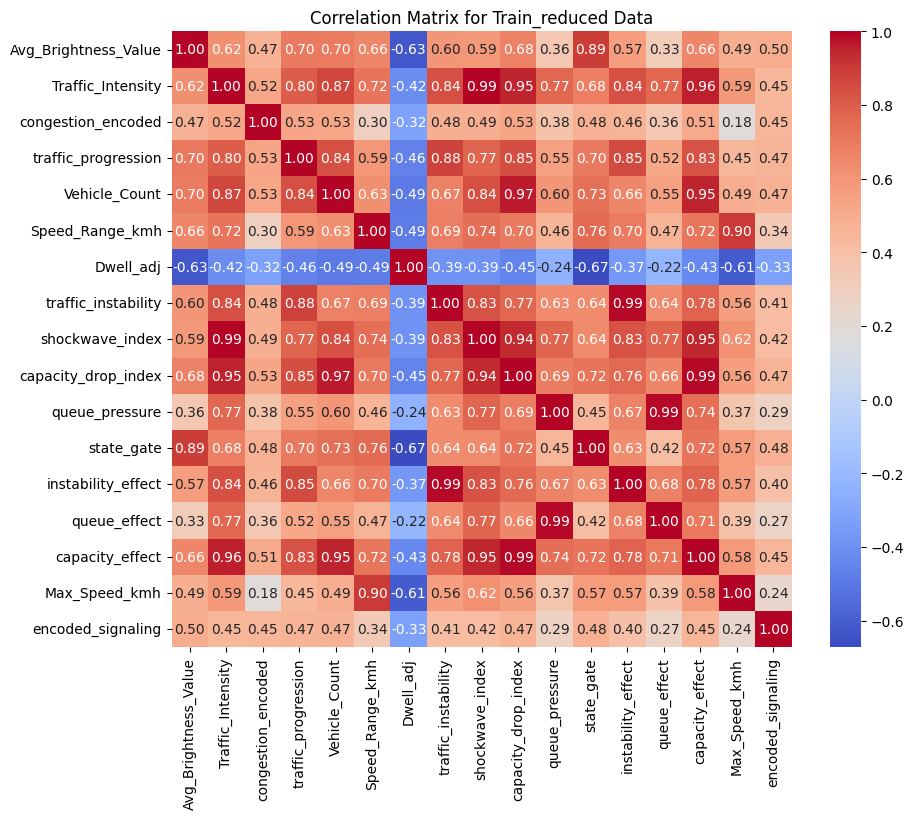

Correlation matrix for Train_reduced displayed.


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for correlation matrix in Train_reduced
numerical_cols_train = ['Avg_Brightness_Value',
                        'Traffic_Intensity',
                        'congestion_encoded',
                        'traffic_progression',
                        'Vehicle_Count',
                        'Speed_Range_kmh',
                        'Dwell_adj',
                        'traffic_instability',
                        'shockwave_index',
                        'capacity_drop_index',
                        'queue_pressure',
                        'state_gate',
                        'instability_effect',
                        'queue_effect',
                        'capacity_effect',
                        'Max_Speed_kmh',
                        'encoded_signaling'
                        ]
correlation_matrix_train = Train_reduced[numerical_cols_train].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_train, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix for Train_reduced Data')
plt.show()

print("Correlation matrix for Train_reduced displayed.")

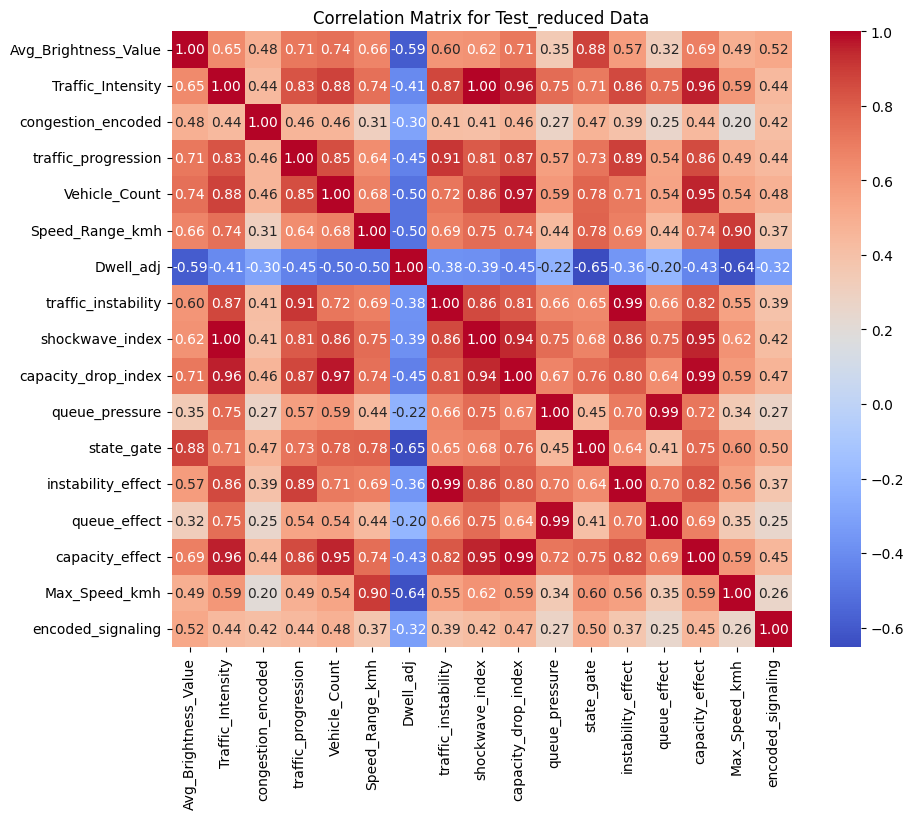

Correlation matrix for Test_reduced displayed.


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for correlation matrix in Test_reduced
numerical_cols_test = ['Avg_Brightness_Value',
                        'Traffic_Intensity',
                        'congestion_encoded',
                        'traffic_progression',
                        'Vehicle_Count',
                        'Speed_Range_kmh',
                        'Dwell_adj',
                        'traffic_instability',
                        'shockwave_index',
                        'capacity_drop_index',
                        'queue_pressure',
                        'state_gate',
                        'instability_effect',
                        'queue_effect',
                        'capacity_effect',
                        'Max_Speed_kmh',
                        'encoded_signaling',

                        ]
correlation_matrix_test = Test_reduced[numerical_cols_test].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_test, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix for Test_reduced Data')
plt.show()

print("Correlation matrix for Test_reduced displayed.")

In [33]:
Train_reduced.columns

Index(['responseId', 'view_label', 'videos', 'video_time',
       'datetimestamp_start', 'datetimestamp_end', 'date', 'signaling',
       'time_segment_id', 'ID', 'congestion', 'Vehicle_Count', 'Avg_Speed_kmh',
       'Max_Speed_kmh', 'Min_Speed_kmh', 'Speed_Range_kmh', 'Speed_Std_kmh',
       'Avg_Brightness_Value', 'Day_Night_Label', 'Traffic_Intensity',
       'Dwell_adj', 'continuity_break', 'prev_2_segments_imputed',
       'prev_3_segments_imputed', 'prev_4_segments_imputed',
       'prev_5_segments_imputed', 'prev_6_segments_imputed',
       'traffic_progression', 'traffic_instability', 'shockwave_index',
       'capacity_drop_index', 'queue_pressure', 'state_gate',
       'instability_effect', 'queue_effect', 'capacity_effect',
       'encoded_signaling', 'congestion_encoded'],
      dtype='object')

In [34]:
columns_to_drop = [
    'continuity_break',
    'prev_2_segments_imputed',
    'prev_3_segments_imputed',
    'prev_4_segments_imputed',
    'prev_5_segments_imputed',
    'prev_6_segments_imputed',
    'responseId',
    'Min_Speed_kmh',
    'Day_Night_Label',

]

Train_reduced = Train_reduced.drop(columns=columns_to_drop)
Test_reduced = Test_reduced.drop(columns=columns_to_drop)

print("Dropped the specified columns from Train_reduced and Test_reduced.")
print("Train_reduced columns:", Train_reduced.columns.tolist())
print("Test_reduced columns:", Test_reduced.columns.tolist())

Dropped the specified columns from Train_reduced and Test_reduced.
Train_reduced columns: ['view_label', 'videos', 'video_time', 'datetimestamp_start', 'datetimestamp_end', 'date', 'signaling', 'time_segment_id', 'ID', 'congestion', 'Vehicle_Count', 'Avg_Speed_kmh', 'Max_Speed_kmh', 'Speed_Range_kmh', 'Speed_Std_kmh', 'Avg_Brightness_Value', 'Traffic_Intensity', 'Dwell_adj', 'traffic_progression', 'traffic_instability', 'shockwave_index', 'capacity_drop_index', 'queue_pressure', 'state_gate', 'instability_effect', 'queue_effect', 'capacity_effect', 'encoded_signaling', 'congestion_encoded']
Test_reduced columns: ['view_label', 'videos', 'video_time', 'datetimestamp_start', 'datetimestamp_end', 'date', 'signaling', 'time_segment_id', 'ID', 'congestion', 'Vehicle_Count', 'Avg_Speed_kmh', 'Max_Speed_kmh', 'Speed_Range_kmh', 'Speed_Std_kmh', 'Avg_Brightness_Value', 'Traffic_Intensity', 'Dwell_adj', 'traffic_progression', 'traffic_instability', 'shockwave_index', 'capacity_drop_index', 'que

In [35]:
Train_reduced.to_csv('Train_reduced.csv', index=False)
Test_reduced.to_csv('Test_reduced.csv', index=False)

We now know some solumns are extreamly correlated and all affect at different rates the congestion type.But then another question comes in how do they all contribute when put together determine to the congestion type? and which are the main factors that we would need that would even help in predicting few minutes into the future?.To help in our decision we created a simple classification model given a specific road at a specific time has certain conditions with also a few history labels how well do they align together all this factors to help in classifying the traffic condition.

## Classification Model Preparation

## Extract Hour Feature



In [36]:
Train_reduced['video_time'] = pd.to_datetime(Train_reduced['video_time'])
Train_reduced['hour'] = Train_reduced['video_time'].dt.hour

Test_reduced['video_time'] = pd.to_datetime(Test_reduced['video_time'])
Test_reduced['hour'] = Test_reduced['video_time'].dt.hour

print("Train_reduced with 'hour' column (first 5 rows):")
print(Train_reduced[['video_time', 'hour']].head())

print("\nTest_reduced with 'hour' column (first 5 rows):")
print(Test_reduced[['video_time', 'hour']].head())

Train_reduced with 'hour' column (first 5 rows):
           video_time  hour
0 2025-10-20 06:05:45     6
1 2025-10-20 06:06:45     6
2 2025-10-20 06:07:45     6
3 2025-10-20 06:08:45     6
4 2025-10-20 06:09:45     6

Test_reduced with 'hour' column (first 5 rows):
           video_time  hour
0 2025-10-20 07:52:45     7
1 2025-10-20 07:53:45     7
2 2025-10-20 07:54:45     7
3 2025-10-20 07:55:45     7
4 2025-10-20 07:56:45     7


## Combine Train and Test Data




In [37]:
combined_df = pd.concat([Train_reduced, Test_reduced], ignore_index=True)

print("Shape of combined_df:", combined_df.shape)
print("\nFirst 5 rows of combined_df:")
print(combined_df.head())

Shape of combined_df: (11654, 30)

First 5 rows of combined_df:
        view_label                                             videos  \
0  Norman Niles #1  normanniles1/normanniles1_2025-10-20-06-05-45.mp4   
1  Norman Niles #1  normanniles1/normanniles1_2025-10-20-06-06-45.mp4   
2  Norman Niles #1  normanniles1/normanniles1_2025-10-20-06-07-45.mp4   
3  Norman Niles #1  normanniles1/normanniles1_2025-10-20-06-08-45.mp4   
4  Norman Niles #1  normanniles1/normanniles1_2025-10-20-06-09-45.mp4   

           video_time  datetimestamp_start    datetimestamp_end        date  \
0 2025-10-20 06:05:45  2025-10-20 06:05:45  2025-10-20 06:06:44  2025-10-20   
1 2025-10-20 06:06:45  2025-10-20 06:06:45  2025-10-20 06:07:44  2025-10-20   
2 2025-10-20 06:07:45  2025-10-20 06:07:45  2025-10-20 06:08:44  2025-10-20   
3 2025-10-20 06:08:45  2025-10-20 06:08:45  2025-10-20 06:09:44  2025-10-20   
4 2025-10-20 06:09:45  2025-10-20 06:09:45  2025-10-20 06:10:44  2025-10-20   

  signaling  time_segm

## Prepare Features and Target for CatBoost




In [38]:
numerical_features = [
    'Avg_Brightness_Value',
    'Traffic_Intensity',
    'traffic_progression',
    'Vehicle_Count',
    'Speed_Range_kmh',
    'Dwell_adj',
    'traffic_instability',
    'shockwave_index',
    'capacity_drop_index',
    'queue_pressure',
    'state_gate',
    'instability_effect',
    'queue_effect',
    'capacity_effect',
    'Max_Speed_kmh',
    'encoded_signaling',
    'hour'
]

categorical_features = [
    'view_label',
]

# Create feature matrix X and target vector y
X = combined_df[numerical_features + categorical_features]
y = combined_df['congestion_encoded']

print("Head of X:")
print(X.head())

print("\nHead of y:")
print(y.head())

Head of X:
   Avg_Brightness_Value  Traffic_Intensity  traffic_progression  \
0                 69.66           0.158730             0.158730   
1                 69.42           3.137255             0.158730   
2                 70.29           0.267835             1.647993   
3                 69.44           0.149031             1.290861   
4                 69.14           0.000000             0.835556   

   Vehicle_Count  Speed_Range_kmh     Dwell_adj  traffic_instability  \
0              1             0.00  6.621314e+00             0.000000   
1              4             2.81  2.717453e+01             0.242931   
2              2             0.04  5.733845e+00             0.009942   
3              1             0.00  6.164698e+00             0.000000   
4              0             0.00  3.600000e+07             0.000000   

   shockwave_index  capacity_drop_index  queue_pressure  state_gate  \
0         0.000000             0.000000        0.183925    0.000000   
1         1

## Split Data into Training and Validation Sets



In [39]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

# Print the shapes of the resulting datasets
print("Shape of X_train:", X_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_val:", y_val.shape)

# Verify the normalized value counts for the target variable
print("\nNormalized value counts for y_train:\n", y_train.value_counts(normalize=True))
print("\nNormalized value counts for y_val:\n", y_val.value_counts(normalize=True))

Shape of X_train: (10488, 18)
Shape of X_val: (1166, 18)
Shape of y_train: (10488,)
Shape of y_val: (1166,)

Normalized value counts for y_train:
 congestion_encoded
0    0.598017
1    0.153795
3    0.126335
2    0.121854
Name: proportion, dtype: float64

Normalized value counts for y_val:
 congestion_encoded
0    0.597770
1    0.154374
3    0.126072
2    0.121784
Name: proportion, dtype: float64


## Train and Evaluate CatBoost Model




In [40]:
import optuna
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import f1_score, accuracy_score
import torch

# Define categorical features, as used in model training
cat_features_for_model = ['view_label']

def objective(trial):
    # 3. Suggest hyperparameters for CatBoostClassifier
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10, log=True),
        'random_seed': 42,
        'verbose': 0,
        'early_stopping_rounds': 50,
        'cat_features': cat_features_for_model,
        'eval_metric': 'Accuracy', # Changed from 'Logloss' to 'Accuracy'
        'loss_function': 'MultiClass' # Explicitly set loss function for multi-class
    }

    # Check for GPU availability and set task_type accordingly
    if torch.cuda.is_available():
        params['task_type'] = 'GPU'
        params['devices'] = '0'
    else:
        params['task_type'] = 'CPU'

    # 5. Initialize a CatBoostClassifier with suggested hyperparameters
    model = CatBoostClassifier(**params)

    # 6. Train the CatBoostClassifier
    model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50, verbose=0)

    # 7. Make predictions on the validation set
    y_pred = model.predict(X_val)

    # 8. Calculate weighted F1-score and Accuracy
    f1 = f1_score(y_val, y_pred, average='weighted')
    accuracy = accuracy_score(y_val, y_pred)

    # 9. Compute the combined score
    combined_score = (0.7 * f1) + (0.3 * accuracy)

    # 10. Return the combined score
    return combined_score

print("Optuna objective function 'objective' defined successfully.")

Optuna objective function 'objective' defined successfully.


In [41]:
import optuna
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import f1_score, accuracy_score
import torch
from optuna.samplers import TPESampler # Import TPESampler

# Create an Optuna study object
# We want to maximize the combined score, so set direction='maximize'
sampler = TPESampler(seed=42) # Seed the TPE sampler for reproducibility
study = optuna.create_study(direction='maximize', sampler=sampler)

# Optimize the study using the objective function for 100 trials
print("Starting Optuna hyperparameter optimization...")
study.optimize(objective, n_trials=200)
print("Optuna optimization completed.")

# Print the best trial's value (combined score)
print(f"\nBest trial's combined score (0.7*F1 + 0.3*Accuracy): {study.best_value:.4f}")

# Print the best trial's parameters
best_params = study.best_trial.params
print("Best trial's parameters:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

# Re-initialize the final model with the best parameters found by Optuna
print("\nInitializing final CatBoost model with best parameters...")
final_model_params = best_params.copy()
final_model_params['random_seed'] = 42
final_model_params['verbose'] = 0
final_model_params['early_stopping_rounds'] = 50
final_model_params['cat_features'] = cat_features_for_model
final_model_params['eval_metric'] = 'Accuracy' # Set to Accuracy for final model too
final_model_params['loss_function'] = 'MultiClass' # Explicitly set for final model

# Ensure task_type is set correctly for the final model
if torch.cuda.is_available():
    final_model_params['task_type'] = 'GPU'
    final_model_params['devices'] = '0'
else:
    final_model_params['task_type'] = 'CPU'

final_model = CatBoostClassifier(**final_model_params)

# Train the final model on the full training data
print("Training final CatBoost model...")
final_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50, verbose=0)
print("Final CatBoost model training completed.")

# Make predictions on the validation set using the final model
y_pred_final = final_model.predict(X_val)

# Calculate F1-score and Accuracy for the final model
f1_final = f1_score(y_val, y_pred_final, average='weighted')
accuracy_final = accuracy_score(y_val, y_pred_final)

# Display the results for the final model
print(f"\nFinal model Weighted F1-score on validation set: {f1_final:.4f}")
print(f"Final model Accuracy on validation set: {accuracy_final:.4f}")

[I 2026-01-27 12:51:00,196] A new study created in memory with name: no-name-3a39a9bf-88fc-4ac6-8412-56f01319e4ab


Starting Optuna hyperparameter optimization...


[I 2026-01-27 12:51:06,555] Trial 0 finished with value: 0.6690451297937303 and parameters: {'iterations': 437, 'learning_rate': 0.2536999076681772, 'depth': 9, 'l2_leaf_reg': 0.6251373574521749}. Best is trial 0 with value: 0.6690451297937303.
[I 2026-01-27 12:51:14,581] Trial 1 finished with value: 0.6394351721297283 and parameters: {'iterations': 240, 'learning_rate': 0.01699897838270077, 'depth': 4, 'l2_leaf_reg': 3.9676050770529883}. Best is trial 0 with value: 0.6690451297937303.
[I 2026-01-27 12:51:16,027] Trial 2 finished with value: 0.6467478220982257 and parameters: {'iterations': 641, 'learning_rate': 0.11114989443094977, 'depth': 4, 'l2_leaf_reg': 8.123245085588687}. Best is trial 0 with value: 0.6690451297937303.
[I 2026-01-27 12:51:17,914] Trial 3 finished with value: 0.6518589400818394 and parameters: {'iterations': 850, 'learning_rate': 0.020589728197687916, 'depth': 5, 'l2_leaf_reg': 0.03549878832196503}. Best is trial 0 with value: 0.6690451297937303.
[I 2026-01-27 12

Optuna optimization completed.

Best trial's combined score (0.7*F1 + 0.3*Accuracy): 0.6734
Best trial's parameters:
  iterations: 201
  learning_rate: 0.1415630828867742
  depth: 7
  l2_leaf_reg: 1.1514360643951977

Initializing final CatBoost model with best parameters...
Training final CatBoost model...
Final CatBoost model training completed.

Final model Weighted F1-score on validation set: 0.6647
Final model Accuracy on validation set: 0.6938


## Confusion Matrix

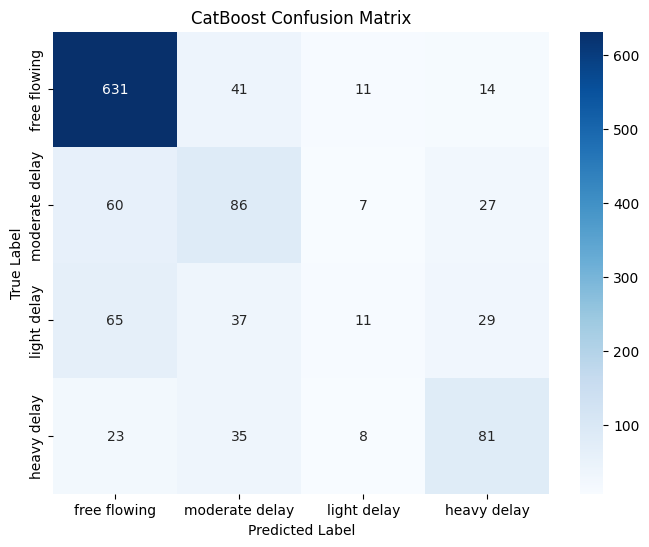

Confusion matrix visualized for CatBoost model.


In [42]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

_, class_names_ordered = pd.factorize(combined_df['congestion'].unique())

_, actual_class_names = pd.factorize(Train_reduced['congestion'])


# Get the unique congestion values and their encoded integers from the combined_df
congestion_map = {label: encoded_val for encoded_val, label in enumerate(combined_df['congestion'].unique())}

# Sort the labels by their encoded value to ensure correct order in the plot
sorted_class_names = sorted(congestion_map.items(), key=lambda item: item[1])
class_names = [label for label, _ in sorted_class_names]

# Calculate the confusion matrix
cm = confusion_matrix(y_val, y_pred_final)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('CatBoost Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("Confusion matrix visualized for CatBoost model.")

## Feature Importance

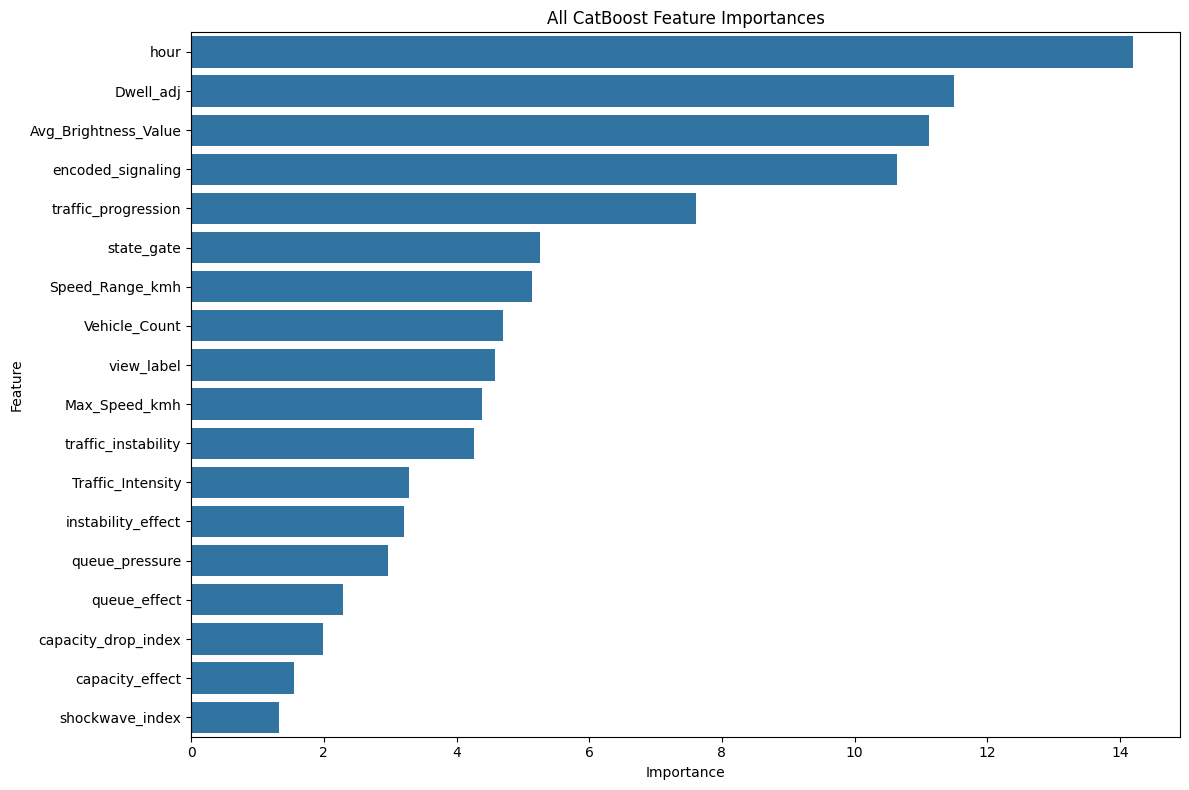

All CatBoost feature importances visualized.


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import Pool

# 1. Extract feature importances

# Define categorical features, as used in model training
cat_features_for_model = ['view_label']

# Create a Pool object for feature importance calculation
feature_importance_pool = Pool(X_train, y_train, cat_features=cat_features_for_model)

feature_importances = final_model.get_feature_importance(feature_importance_pool)

# 2. Map feature importances to feature names
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# 3. Sort feature importances in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 4. Visualize the top features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('All CatBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("All CatBoost feature importances visualized.")

In [44]:
feature_importance_df

,Feature,Importance
16,hour,14.194680
5,Dwell_adj,11.490619
0,Avg_Brightness_Value,11.115194
15,encoded_signaling,10.642113
2,traffic_progression,7.608488
10,state_gate,5.264152
4,Speed_Range_kmh,5.134197
3,Vehicle_Count,4.695236
17,view_label,4.585777
14,Max_Speed_kmh,4.380290


## Feature Importances: Understanding the Drivers of Congestion

Our CatBoost model has identified several key features that significantly contribute to classifying traffic congestion levels. This insight is crucial for understanding the dynamics of traffic and for potentially predicting future conditions. Below, we break down the most impactful features:

1.  **Hour (`hour`) - Importance: 14.19%**
    *   **Explanation:** This feature, derived directly from the `video_time`, captures the time of day. Its high importance indicates that the time of day is the single most influential factor in determining congestion. This is intuitive, as traffic patterns are heavily influenced by rush hours, off-peak times, and even specific times when certain activities (e.g., school runs, work commutes) typically occur. The model leverages this to distinguish between periods of free-flowing traffic, moderate delays, and heavy congestion.

2.  **Adjusted Dwell Time (`Dwell_adj`) - Importance: 11.49%**
    *   **Explanation:** 'Dwell Time' was defined to measure how long vehicles remain within a road segment, adjusted for speed, speed instability, and traffic pressure. Its high importance suggests that the actual time vehicles spend in a given segment, especially when considering the erratic nature of traffic and overall intensity, is a strong indicator of congestion. Higher adjusted dwell times are a direct consequence of vehicles moving slowly or being stopped, which is a hallmark of congested conditions.

3.  **Average Brightness Value (`Avg_Brightness_Value`) - Importance: 11.12%**
    *   **Explanation:** This feature represents the average brightness of the video segment. While seemingly indirect, its significant importance could reflect environmental conditions that correlate with traffic. For example, during daylight hours, visibility is generally better, and traffic patterns might differ from nighttime, dawn, or dusk, when brightness values would be lower. It might also capture the presence of adverse weather conditions (e.g., heavy rain, fog) that reduce brightness and simultaneously impact traffic flow and congestion.

4.  **Encoded Signaling (`encoded_signaling`) - Importance: 10.64%**
    *   **Explanation:** This feature is our numerical representation of the 'signaling' column (none, low, medium, high), indicating the level of traffic control or information provided to drivers. Its high importance suggests that the presence and intensity of signaling play a vital role in influencing traffic flow and, consequently, congestion levels. Well-managed signaling can alleviate congestion, while inadequate or poorly timed signaling can exacerbate it.

5.  **Traffic Progression (`traffic_progression`) - Importance: 7.61%**
    *   **Explanation:** Traffic progression was designed to capture how congestion builds up over previous continuous segments, providing a more stable view than a single traffic reading. Its importance highlights that the historical context of traffic intensity – whether traffic has been steadily building up or clearing – is a critical predictor of the current congestion state. Congestion doesn't just appear; it's a dynamic process, and this feature effectively captures that momentum.

6.  **State Gate (`state_gate`) - Importance: 5.26%**
    *   **Explanation:** The 'state gate' index quantifies how fragmented vehicle speeds are, acting as an indicator for changes in traffic regimes (e.g., from free-flow to stop-and-go). Its importance signifies that the internal dynamics of traffic flow, specifically the variance in speeds among vehicles, are crucial for identifying congested states. A high state gate value indicates that vehicles are no longer moving uniformly, a clear sign of impending or existing congestion.

7.  **Speed Range (`Speed_Range_kmh`) - Importance: 5.13%**
    *   **Explanation:** This feature measures the difference between the maximum and minimum observed speeds within a segment. A larger speed range indicates greater variability in vehicle speeds, often associated with stop-and-go conditions or fragmented traffic flow, both of which are characteristics of congestion. This direct measure of speed inconsistency is therefore a strong indicator of traffic conditions.

8.  **Vehicle Count (`Vehicle_Count`) - Importance: 4.70%**
    *   **Explanation:** The raw number of vehicles in a segment is, as expected, a significant factor. More vehicles generally mean higher density and a greater likelihood of congestion. While other features refine this understanding by considering speed and variability, the sheer volume of traffic remains a fundamental driver of congestion.

These insights demonstrate that our model is not just relying on simple metrics but is effectively using complex, derived features that capture the multi-faceted nature of traffic congestion, including temporal patterns, detailed flow dynamics, and even environmental context.

## Root Causes of Traffic Congestion and Practical Recommendations for Barbados Roundabouts

Based on the feature importance analysis and the specific context of Barbados roundabouts, we can identify key drivers of congestion and propose targeted recommendations.

### Inferred Root Causes of Traffic Congestion:

1.  **Peak-Hour Demand Surges (`hour`):** The dominant influence of the 'hour' feature confirms that traffic on Barbados roundabouts is heavily dictated by predictable daily routines—commutes, school runs, and peak tourist transit—leading to significant congestion during specific times of the day.
2.  **Inefficient Flow Dynamics within the Roundabout (`Dwell_adj`, `Speed_Range_kmh`, `Vehicle_Count`, `state_gate`):** High adjusted dwell times, wide speed ranges, and significant vehicle counts, coupled with changes in traffic 'state,' collectively indicate that the roundabout's design or operational efficiency might be struggling to handle vehicle volumes. Vehicles are spending too long in the roundabout, speeds are inconsistent, and flow breaks down into stop-and-go patterns, often exacerbated by driver behaviour or lack of clear guidance.
3.  **Impact of Traffic Signaling on Feeder Roads (`encoded_signaling`):** The importance of 'encoded_signaling' suggests that traffic lights or other forms of signaling on roads leading *into* or *out of* the roundabout are crucial. Poorly synchronized signals, or a lack of dynamic control, can create bottlenecks and prevent efficient entry/exit from the roundabout, thereby 'choking' its flow.
4.  **Cumulative Congestion Build-up (`traffic_progression`):** The 'traffic_progression' feature highlights that congestion doesn't appear suddenly; it's a gradual process. This implies that small delays or disruptions on an approach can cascade into significant gridlock within and around the roundabout over several minutes.
5.  **Environmental and Visibility Factors (`Avg_Brightness_Value`):** The surprising relevance of 'Avg_Brightness_Value' could point to how external conditions affect traffic. For instance, heavy rainfall common in Barbados can reduce visibility and slow speeds; strong sun glare (common on an island) can impact driver perception; or even differences between daytime and nighttime driving behaviours.

### Practical Recommendations for the Ministry of Transport and Works:

1.  **Dynamic Traffic Signal Optimization for Roundabout Approaches:**
    *   **Action:** Implement intelligent traffic light systems on roads feeding into and exiting the roundabout. These systems should use real-time sensor data to dynamically adjust signal timings, prioritizing flow into and out of the roundabout based on current demand, rather than fixed schedules.
    *   **Benefit:** Reduces queuing on approach roads, preventing gridlock within the roundabout and improving overall flow, especially during peak hours.

2.  **Public Awareness Campaigns on Roundabout Etiquette and Lane Discipline:**
    *   **Action:** Launch targeted educational campaigns (TV, radio, social media) to inform drivers about proper lane usage, signaling, and yielding within roundabouts, particularly for multi-lane roundabouts. Emphasize concepts like 'spiral roundabouts' if they are present or planned.
    *   **Benefit:** Improves driver confidence and predictability, reducing hesitation, conflicts, and stop-and-go incidents caused by misunderstanding rules.



2.  **Real-time Traffic Information and Predictive Alerts:**
    *   **Action:** Develop a system to provide real-time traffic updates (e.g., via radio, local news apps) to Barbadian citizens regarding congestion levels at key roundabouts. Utilize predictive capabilities of the model to issue early warnings for anticipated severe congestion.
    *   **Benefit:** Enables drivers to make informed decisions about departure times or alternative routes, helping to spread demand and mitigate sudden congestion spikes.

3.  **Consider Weather-Adaptive Traffic Management:**
    *   **Action:** Integrate real-time weather data (especially heavy rain warnings) with traffic management systems. During adverse weather, automatically adjust signal timings or issue advisories for drivers to exercise caution and expect delays.
    *   **Benefit:** Proactively manages traffic during conditions that naturally slow vehicle speeds and reduce visibility, which are common on an island.

These recommendations leverage insights from the model's feature importances, focusing on actionable steps that address the identified root causes within the Barbadian context. They aim to not only manage existing congestion but also to proactively mitigate future traffic problems.

In [45]:
model_filename = 'final_catboost_model.cbm'
final_model.save_model(model_filename)
print(f"Final CatBoost model saved to '{model_filename}'")

Final CatBoost model saved to 'final_catboost_model.cbm'


**From the features,overally time had the most decisive features though each feature played a part and the overall score was far beyond average-which is a good sign for traffic problem-But unfortunately efforts to try and use all this features in our predictive model were not that succesfull-didn't give our highest score- and had to rely on time features more which now opened the door to our winning approach the Next notebook.**

# APPROXIMATELY 10 MINUTES TO RUN EVERYTHING 